In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str

In [4]:
parent_llm = init_chat_model("google_genai:gemini-2.5-flash-lite")
subgraph_llm = init_chat_model("google_genai:gemini-2.5-flash-lite")

In [5]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [6]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)
subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [7]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [8]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)
parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

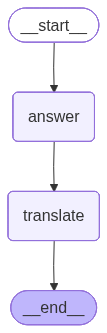

In [9]:
graph = parent_builder.compile()
graph

In [10]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics is a **fundamental theory in physics that describes the physical properties of nature at the scale of atoms and subatomic particles.** It\'s a realm where our everyday intuition about how the world works breaks down, and phenomena behave in ways that are often counterintuitive and bizarre from a classical perspective.\n\nHere are some of the key concepts and characteristics of quantum physics:\n\n*   **Quantization:** This is the core idea. Many physical properties, such as energy, momentum, and angular momentum, are not continuous but exist in discrete packets or "quanta." Imagine a ramp versus stairs; in the quantum world, things are more like stairs, where you can only be on specific steps, not in between.\n\n*   **Wave-Particle Duality:** One of the most mind-bending aspects is that quantum objects can exhibit both wave-like and particle-like behavior. An electron, for instance, can act like a tiny, localized p